# 01-01 : PaddleOCR

Perform a basic test of OCR on a PDF file using the PaddleOCR engine.

In [1]:
import os
import subprocess

import cv2
import fitz
import numpy as np
from paddleocr import PaddleOCR, draw_ocr, PPStructure, save_structure_res
from PIL import Image

/home/johnny/swan/miniconda3/envs/trs-extraction/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


## 1. Configuration

In [2]:
data_path = '../../../data'
test_path = f'{data_path}/test'
samples_path = f'{test_path}/sample_pdf'

output_path = f'{data_path}/output'
output_pdf_path = f'{output_path}/sample_pdf'
current_output_path = f'{output_pdf_path}/paddle'

font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"


## 2. Get Sample PDF List

In [3]:
# get a list of all the pdf files in the sample_pdf directory
pdf_files = os.listdir(samples_path)
pdf_files = [f for f in pdf_files if f.endswith('.pdf')]
pdf_files.sort()

# show the list of pdf files
print('List of PDF files:')
print(pdf_files)

List of PDF files:
['01.pdf', '02.pdf', '03.pdf', '04.pdf', '05.pdf']


## 3. Basic Test

In [4]:
# page_num=0 processes all pages
ocr = PaddleOCR(use_angle_cls=True, lang='en', page_num=0)

[2025/04/24 15:31:31] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/johnny/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/johnny/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num

In [5]:
# get the absolute path the the pdf file
pdf_path = os.path.abspath(f'{samples_path}/{pdf_files[3]}')
print(f'Absolute path to the first PDF file: {pdf_path}')

# perform OCR on the PDF file
result = ocr.ocr(pdf_path, cls=True)
print(f'Number of pages in the PDF file: {len(result)}')


Absolute path to the first PDF file: /home/johnny/swan/code/trs-extraction/data/test/sample_pdf/04.pdf
[2025/04/24 15:31:32] ppocr DEBUG: dt_boxes num : 27, elapsed : 0.16631770133972168
[2025/04/24 15:31:32] ppocr DEBUG: cls num  : 27, elapsed : 0.03628849983215332
[2025/04/24 15:31:39] ppocr DEBUG: rec_res num  : 27, elapsed : 7.08435583114624
[2025/04/24 15:31:40] ppocr DEBUG: dt_boxes num : 117, elapsed : 0.11894488334655762
[2025/04/24 15:31:40] ppocr DEBUG: cls num  : 117, elapsed : 0.08362412452697754
[2025/04/24 15:31:45] ppocr DEBUG: rec_res num  : 117, elapsed : 5.115238904953003
[2025/04/24 15:31:45] ppocr DEBUG: dt_boxes num : 17, elapsed : 0.09799599647521973
[2025/04/24 15:31:45] ppocr DEBUG: cls num  : 17, elapsed : 0.02646803855895996
[2025/04/24 15:31:47] ppocr DEBUG: rec_res num  : 17, elapsed : 1.724992036819458
[2025/04/24 15:31:47] ppocr DEBUG: dt_boxes num : 59, elapsed : 0.10624003410339355
[2025/04/24 15:31:47] ppocr DEBUG: cls num  : 59, elapsed : 0.04315614700

### 3.1 Visualize the results

In [6]:
def visualize_ocr_results(pdf_path, result, font_path):
    imgs = []
    with fitz.open(pdf_path) as pdf:
        for pg in range(0, len(result)):
            page = pdf[pg]
            mat = fitz.Matrix(2, 2)
            pm = page.get_pixmap(matrix=mat, alpha=False)
            # if width or height > 2000 pixels, don't enlarge the image
            if pm.width > 2000 or pm.height > 2000:
                pm = page.get_pixmap(matrix=fitz.Matrix(1, 1), alpha=False)
            img = Image.frombytes("RGB", [pm.width, pm.height], pm.samples)
            img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
            imgs.append(img)
    for idx in range(len(result)):
        res = result[idx]
        if res is None:
            continue
        image = imgs[idx]
        boxes = [line[0] for line in res]
        txts = [line[1][0] for line in res]
        scores = [line[1][1] for line in res]
        im_show = draw_ocr(image, boxes, txts, scores, font_path=font_path)
        im_show = Image.fromarray(im_show)
        # im_show.save('result_page_{}.jpg'.format(idx))
        #display(im_show)
        
        return im_show

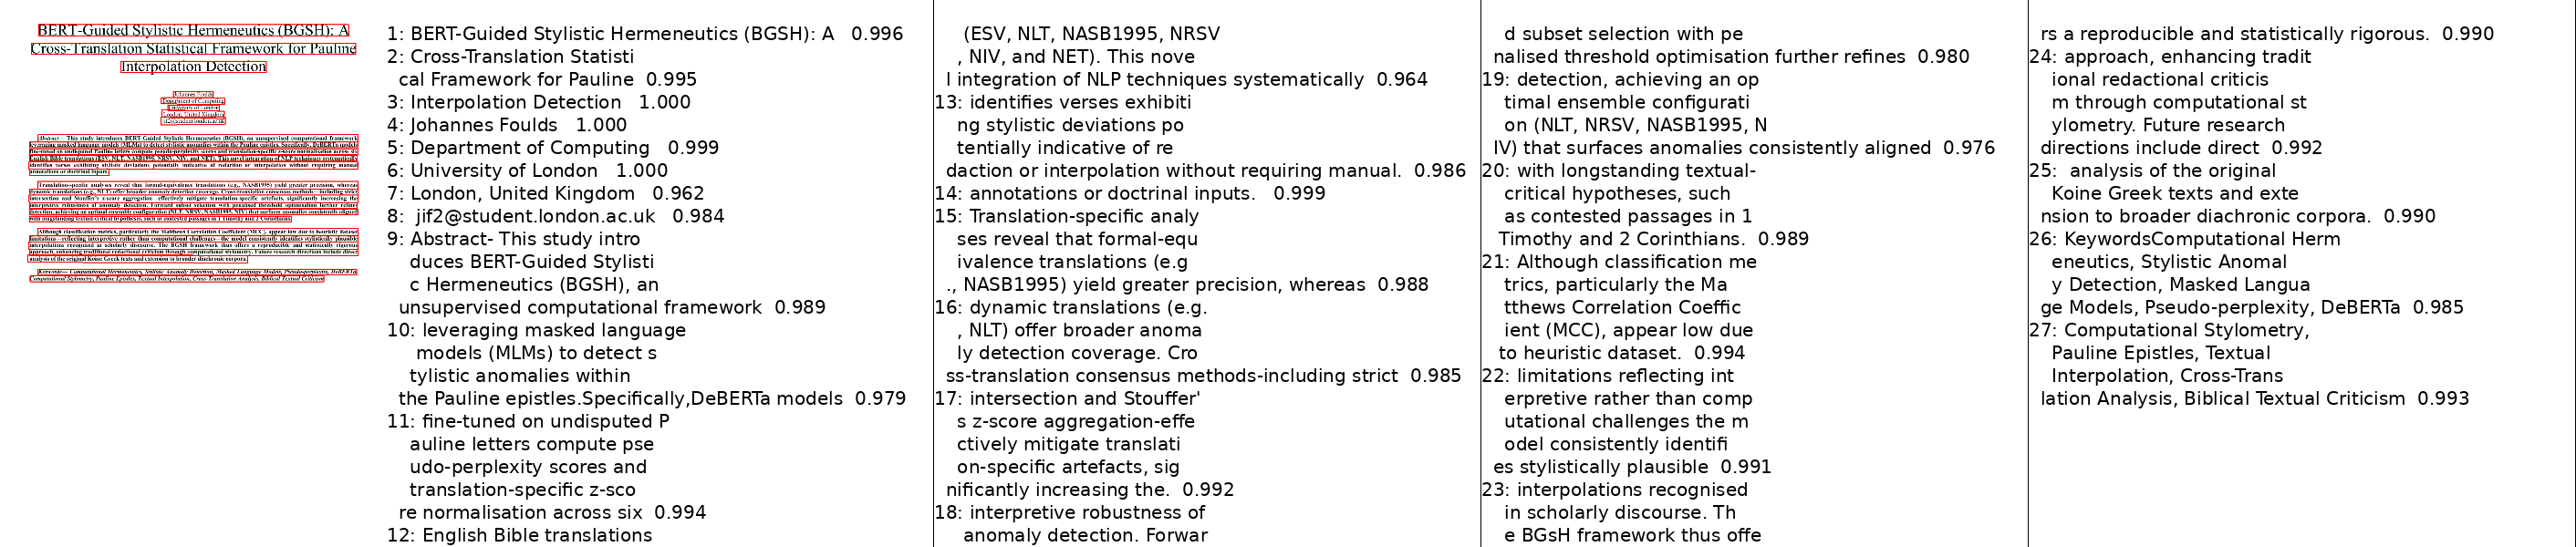

In [7]:
visualize_ocr_results(pdf_path, result, font_path)

In [8]:
#result

### 3.2 Produce Markdown

In [9]:
pdf_engine = PPStructure(recovery=True, layout=True, ocr=True)
result = pdf_engine(pdf_path)

[2025/04/24 15:34:24] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/home/johnny/.paddleocr/whl/det/ch/ch_PP-OCRv4_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/home/johnny/.paddleocr/whl/rec/ch/ch_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num

In [10]:
result

[[{'type': 'text',
   'bbox': [497, 283, 692, 380],
   'img': array([[[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
   
          ...,
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [ 38,  38,  38],
           [162, 162, 162],
           [255, 255, 255]],
   
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
          

In [11]:
save_structure_res(result, current_output_path, 'md')  # This saves as .md files

TypeError: 'str' object cannot be interpreted as an integer